In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

### NEW ###
import arviz as az
import pymc as pm

#Bayesian Analysis
Read:
- Theory: http://www.stat.columbia.edu/~gelman/book/
- PyMC: https://github.com/aloctavodia/BAP3/tree/main

#Coin Flips with biased (?) coins




In [ ]:
data = stats.bernoulli.rvs(0.3, size=100)
data

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0])

*Questions:*
- Is the coin biased?
- Can we estimate p?

**Chat**, discuss the differences between Bayesian and frequentists stats. Use an example of estimating the bias of a coin.

#Frequentist answer:

In [ ]:
p_hat = data.mean() # ~Normal by CLT -> confidence interval
p_hat

np.float64(0.34)

In [ ]:
stats.bootstrap([data],lambda x: x.mean()) #or just do this

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(0.25), high=np.float64(0.44)), bootstrap_distribution=array([0.36, 0.22, 0.45, ..., 0.3 , 0.33, 0.33]), standard_error=np.float64(0.047642513675672266))

#Bayesian answer:
1. p is a random variable.
2. we don't know anything about p at first, except that it's between 0 and 1.

  =>

$$PRIOR(p) = Beta(1,1) = U[0,1]$$



In [ ]:
x = np.linspace(0,1, 100)
def plot_beta(a,b):
  plt.plot(x, stats.beta.pdf(x, a, b),'r-', lw=1, alpha=0.6)
  plt.title(f"Beta(a={a}, b={b})")

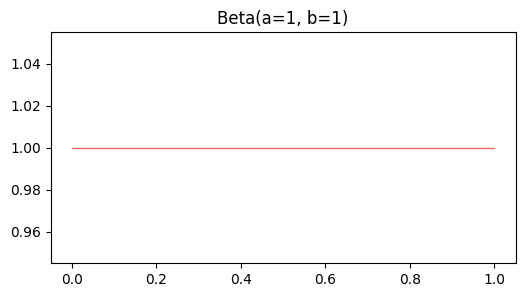

In [ ]:
plt.figure(figsize=(6,3))
plot_beta(1,1)

given $p=x$:
- each coin flip is a $Bernoulli(x)$
- coin flips are independent.

=>

$$LIKELIHOOD(Data|p)=P(Data|p=x)=\prod_{i=1}^n{Bernoulli(x)}=Binomial(n,x)$$


Use Bayes law:
- https://en.wikipedia.org/wiki/Bayes%27_theorem
$$POSTERIOR(p) = P(p|data)=\frac{P(data|p)\cdot P(p)}{P(data)} \propto P(data|p)\cdot P(p)$$

$$POSTERIOR(p)  \propto LIKELIHOOD(data|p)\cdot PRIOR(p)$$

**Chat**, why is a Beta the natural choice for a prior in this case?

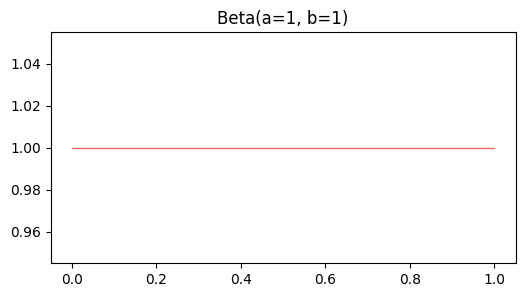

In [ ]:
iterator = iter(data)
a = 1
b = 1
plt.figure(figsize=(6,3))
plot_beta(a,b) #prior

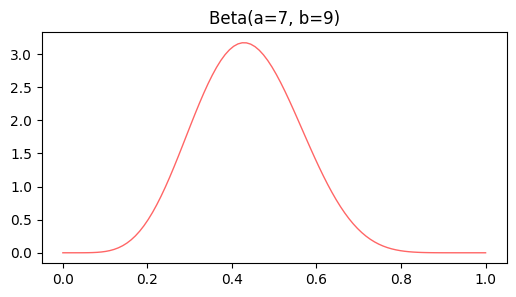

In [ ]:
sample = next(iterator)
a += sample
b += 1 - sample
plt.figure(figsize=(6,3))
plot_beta(a,b) #posterior

In [ ]:
# # this takes a while
# import matplotlib.animation as animation
# from IPython.display import HTML

# fig, ax = plt.subplots(figsize=(6,3))
# x = np.linspace(0,1, 100)
# def animate(i):
#   a = 2
#   b = 2
#   for sample in data[:i]:
#     a += sample
#     b += 1 - sample
#   ax.clear()
#   ax.plot(x, stats.beta.pdf(x, a, b),'r-', lw=1, alpha=0.6);
#   ax.set_title(f"Beta(a={a}, b={b})")

# anim = animation.FuncAnimation(fig, animate, frames=len(data));
# HTML(anim.to_html5_video())

#in PyMC

In [ ]:
data = stats.bernoulli.rvs(0.3, size=50)
data

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0])

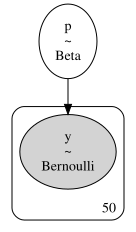

In [ ]:
betabin = pm.Model()
with betabin:
    p = pm.Beta('p', alpha=1., beta=1.)
    y = pm.Bernoulli('y', p=p, observed=data)
pm.model_to_graphviz(betabin)



## Posterior?
- 99% of the time:
  - $P(Data)$ is intractable.
  - No analytic posterior.
- Approximate it with a MCMC sample.

https://chi-feng.github.io/mcmc-demo/

**Chat**,
1. What's MCMC? How can we use it to estimate the posterior without calculating P(data)?
2. Is there any reason to use MCMC to estimate posterior distributions when the closed form is known?
3. My prof said MCMC is the worst sampling algorithm available, but the only one that does the job. What's your take?

In [ ]:
with betabin:
  idata = pm.sample(1000,chains=4)


Output()

In [ ]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

**Chat**,
1. Explain context managers in python and rewrite this code snippet without syntactic sugar.
2. Explain the output of `pm.sample()`.

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

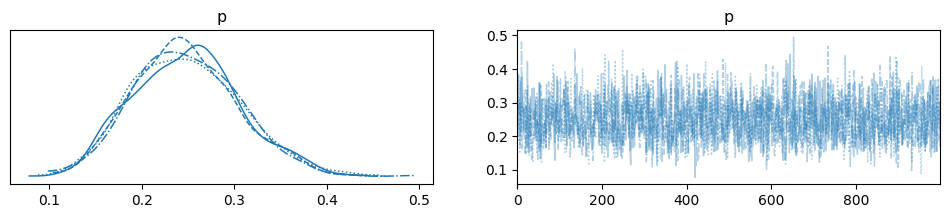

In [ ]:
az.plot_trace(idata)

**Chat**, what do you think about these trace plots?

## Bayesian Inference
https://rpsychologist.com/d3/bayes/

### Credible intervals

<Axes: title={'center': 'p'}>

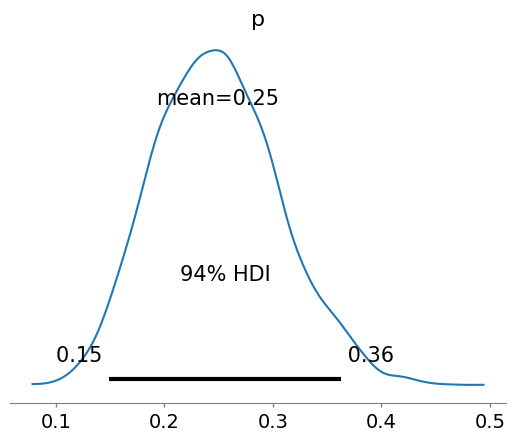

In [ ]:
az.plot_posterior(idata)

In [ ]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.249,0.058,0.149,0.363,0.001,0.001,1701.0,2570.0,1.0


**Chat**, what's HDI? Compare to frequentist confidence intervals.
  - What about other credible intervals?
  - Draw a figure with matplotlib illustrating the difference between central credible intervals and HDIs.

### Hypotheses testing: Bayes factor

The reference value is outside of the posterior. This translate into infinite support for H1, which is most likely an overstatement.


({'BF10': np.float64(36.05841386569297),
  'BF01': np.float64(0.027732778366921715)},
 <Axes: title={'center': 'The BF_10 is 36.06\nThe BF_01 is 0.03'}, xlabel='p', ylabel='Density'>)

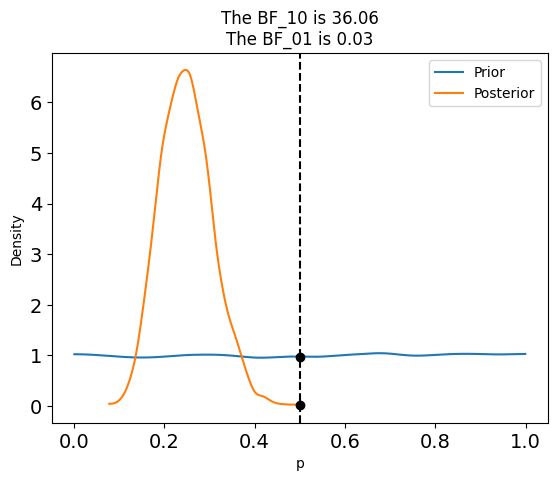

In [ ]:
az.plot_bf(idata,var_name="p",prior=np.random.uniform(0, 1, 10_000),ref_val=0.5)

**Chat**,
1. What's the bayes factor? Compare it to the frequentist counterpart in the context of hypotheses testing.
2. `az.plot_bf(idata,var_name="p",prior=np.random.uniform(0, 1, 10_000),ref_val=0.5)` - What's H0 and H1 here? Explain how arviz calculates the BF. Mention the Savage-Dickey density ratio and give an intuitive explanation for its validity.
3. How should I interpert the BF? Give me a scale.
4. Can I use the BF to test more elaborate hypotheses? What are the pitfalls?

### Bayes estimators
**Chat**,
1. I'm doing bayesian inference. Is there any use case where I would need a point estimate for a parameter?
2. What's the difference between a point estimate and a Bayes estimator?
3. What are the common bayes estimator, and the relevant loss functions?
4. Give an example for a real life scenario in which one of the usual Bayes estimators (mean, median, mode) is the clear choice.

In [ ]:
post_p = idata.posterior['p']
post_p.to_numpy()

array([[0.29181962, 0.27184888, 0.26639468, ..., 0.23011916, 0.26441988,
        0.27295182],
       [0.32366816, 0.37355732, 0.38025159, ..., 0.24033571, 0.26779153,
        0.22413024],
       [0.2314706 , 0.25998963, 0.29809194, ..., 0.2974964 , 0.30793198,
        0.16192862],
       [0.18191551, 0.20151332, 0.23427675, ..., 0.25991647, 0.3004116 ,
        0.3004116 ]])

In [ ]:
L2 = np.mean((post_p.to_numpy().reshape(-1,1)-x.reshape(1,-1))**2,axis=0)
L1 = np.mean(abs(post_p.to_numpy().reshape(-1,1)-x.reshape(1,-1)),axis=0)
print((x[L2.argmin()],post_p.to_numpy().mean()))
print((x[L1.argmin()],np.median(post_p.to_numpy())))

(np.float64(0.25252525252525254), np.float64(0.24900628446226025))
(np.float64(0.24242424242424243), np.float64(0.24645149196855))


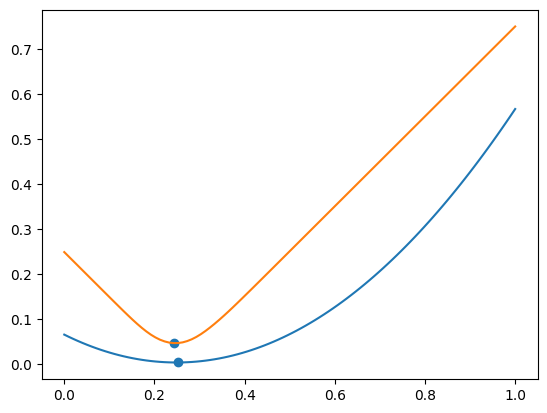

In [ ]:
plt.plot(x,L2)
plt.plot(x,L1)
plt.scatter(x[[L2.argmin(),L1.argmin()]],[L2.min(),L1.min()])

#Posterior predictive

**Chat**,
1. What's the difference between a posterior and a posterior predictive? Use the coin tossing example and mention the beta-binomial.
2. How would I sample from the beta-binomial?
  - Is this MCMC?
  - How would I sample a binomial? What's the algorithm?

In [ ]:
pm.sample_posterior_predictive(idata, model=betabin, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [ ]:
idata.posterior_predictive['y'] # y_dim_2 = ?

<xarray.DataArray 'y' (chain: 4, draw: 1000, y_dim_0: 50)> Size: 2MB
array([[[0, 0, 1, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 1, 1, 1]],

       [[1, 0, 0, ..., 0, 0, 0],
        [1, 1, 0, ..., 1, 1, 0],
        [1, 1, 1, ..., 0, 0, 1],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 1, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 1, ..., 0, 0, 1],
        [1, 1, 1, ..., 0, 1, 0],
        [1, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 1],
        [1, 0, 0, ..., 0, 0, 1],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 1]]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * y_dim_0  (y_dim_0) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49

In [ ]:
idata.posterior_predictive['y'][0,0,:] # = data like sample runs.

<xarray.DataArray 'y' (y_dim_0: 50)> Size: 400B
array([0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0])
Coordinates:
  * y_dim_0  (y_dim_0) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    chain    int64 8B 0
    draw     int64 8B 0

#Many coins
The setup:
- We have X coins.
- They came from the same mint (same batch).
- We flip them bunch of times.


In [ ]:
bias = np.linspace(0.1,0.9,3).reshape(-1,1)
data = np.random.uniform(0,1,size=(len(bias),100)) < bias # data[k,:] ~ Bernoulli(bias[k])

numel = data.size
shape = data.shape

print(shape, numel, data.mean(axis=1), data, sep="\n")

(3, 100)
300
[0.07 0.51 0.95]
[[False False False False False False False False False False False False
  False False False False False False False False  True False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False  True
  False False False False  True False False False False False False False
  False False False False False False False False False False  True False
  False False False False False False False False False False False False
  False False False False False False False False False  True  True False
  False False False  True]
 [False  True False  True  True False  True  True False False False  True
   True False  True  True False False False False False  True False  True
  False  True  True False False  True False False  True  True  True False
   True  True False  True  True  True  True False  True  True  True False
  False False False False  True  True  True False  True

Questions:
- Are the coins fair, on average?
  - `data = data.reshape(-1,1)` and run the analysis above
- Is each coin fair?
  - `data[k,:]` ...
- Is coin #1 more head-biased than coin #2?
- Is the mint biased?

#Independent model

In [ ]:
data = data.reshape(numel)
idx = np.unravel_index(np.arange(numel), shape)[0] #Chat, What does this line do?
print(data.shape)
print(idx)

#Uncomment for the second run:
#flip the last coin just 5 times:
idx = idx[:205]
data= data[:205]

(300,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2]


Output()

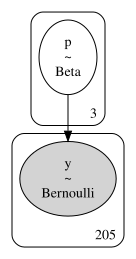

In [ ]:
betabin_vec = pm.Model()
with betabin_vec:
    p = pm.Beta('p', alpha=1., beta=1.,shape=len(bias))
    y = pm.Bernoulli('y', p=p[idx], observed=data)
    idata_vec = pm.sample(1000,chains=2,idata_kwargs={"log_likelihood": True})
pm.model_to_graphviz(betabin_vec)

In [ ]:
az.summary(idata_vec)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[0],0.079,0.026,0.033,0.126,0.000,0.001,3093.0,1458.0,1.0
p[1],0.510,0.050,0.422,0.608,0.001,0.001,3101.0,1440.0,1.0
p[2],0.715,0.153,0.432,0.975,0.003,0.003,2890.0,1417.0,1.0


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

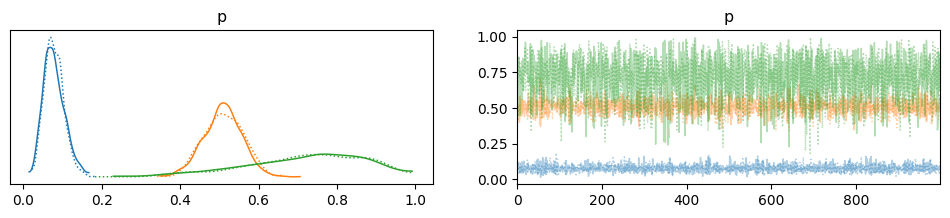

In [ ]:
az.plot_trace(idata_vec)

array([<Axes: title={'center': 'p\n0'}>, <Axes: title={'center': 'p\n1'}>,
       <Axes: title={'center': 'p\n2'}>], dtype=object)

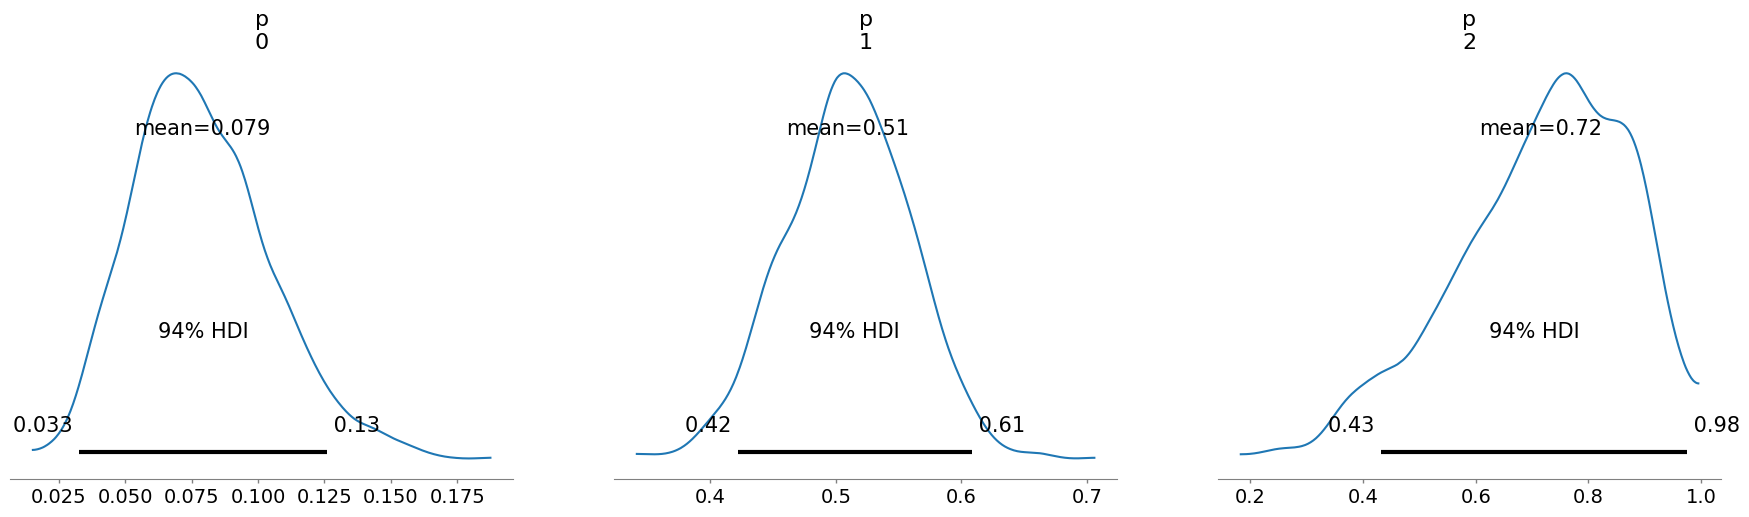

In [ ]:
az.plot_posterior(idata_vec)

#Hierarchical model
- Assumption: the coins come from the same mint - they're not independent.



Output()

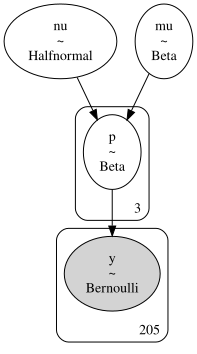

In [ ]:
betabin_h = pm.Model()
with betabin_h:
    # hypyerpriors
    mu = pm.Beta('mu', 2., 2.)    #mu - E[p]
    nu = pm.HalfNormal('nu',30)  #nu = "sample size" = approx. 1/std

    p = pm.Beta('p', mu=mu, nu=nu,shape=len(bias))
    y = pm.Bernoulli('y', p=p[idx], observed=data)
    idata_h = pm.sample(1000,chains=2,idata_kwargs={"log_likelihood": True})
pm.model_to_graphviz(betabin_h)

**Chat**,
1. Are hierarchical Bayesian models popular as a modelling tool? Why?
2. Compare the different parametrizations of a Beta dist.: Beta(\alpha, \beta) vs Beta(\mu, \nu). What do the parameters mean in each case?
  - How is \nu and Var[X] related?
3. What's a hyperprior?
4. Why is the choice of hyperpriors for a Beta prior here reasonable? `mu = pm.Beta('mu', 2., 2.), nu = pm.HalfNormal('nu',100)`. Discuss both the choice of distributions and the chosen parameters.

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

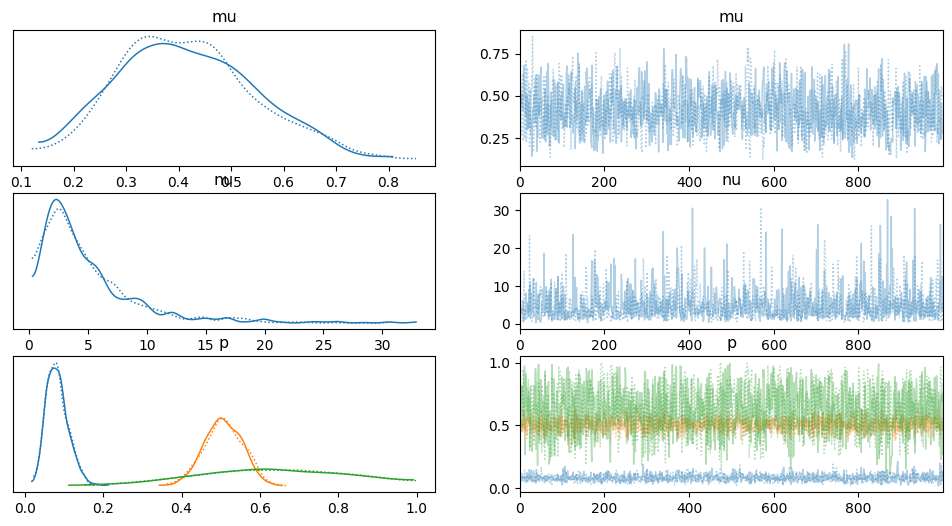

In [ ]:
az.plot_trace(idata_h)

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'nu'}>,
        <Axes: title={'center': 'p\n0'}>],
       [<Axes: title={'center': 'p\n1'}>,
        <Axes: title={'center': 'p\n2'}>, <Axes: >]], dtype=object)

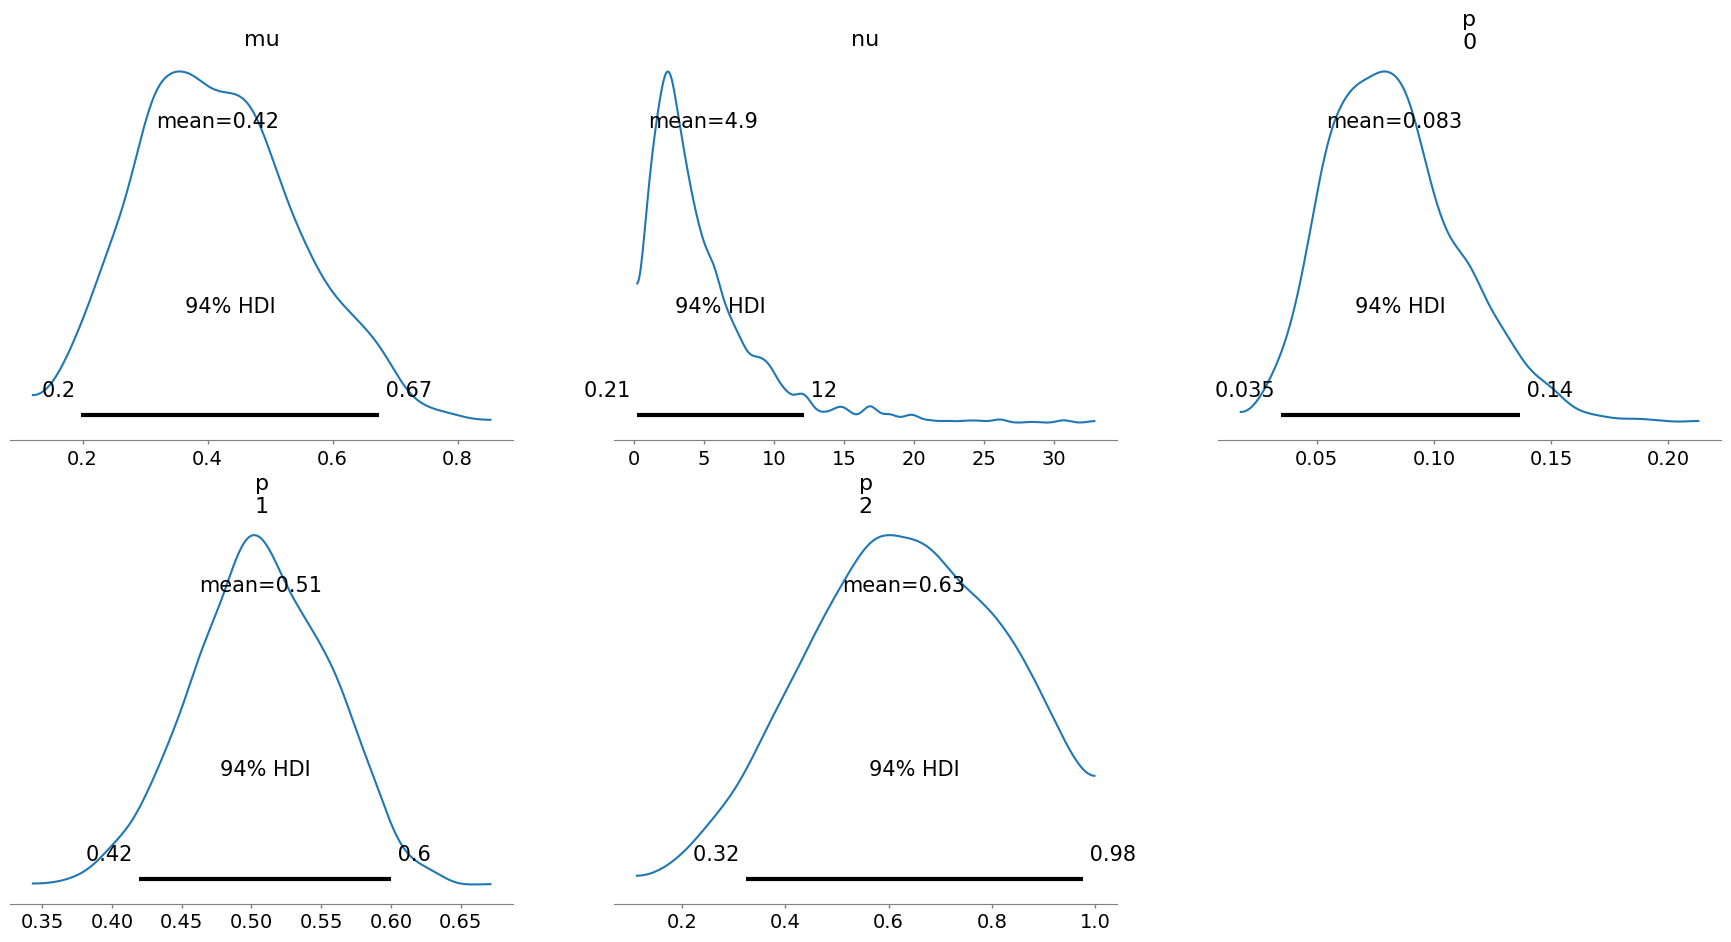

In [ ]:
az.plot_posterior(idata_h)

array([<Axes: title={'center': 'p\n0'}>, <Axes: title={'center': 'p\n1'}>,
       <Axes: title={'center': 'p\n2'}>], dtype=object)

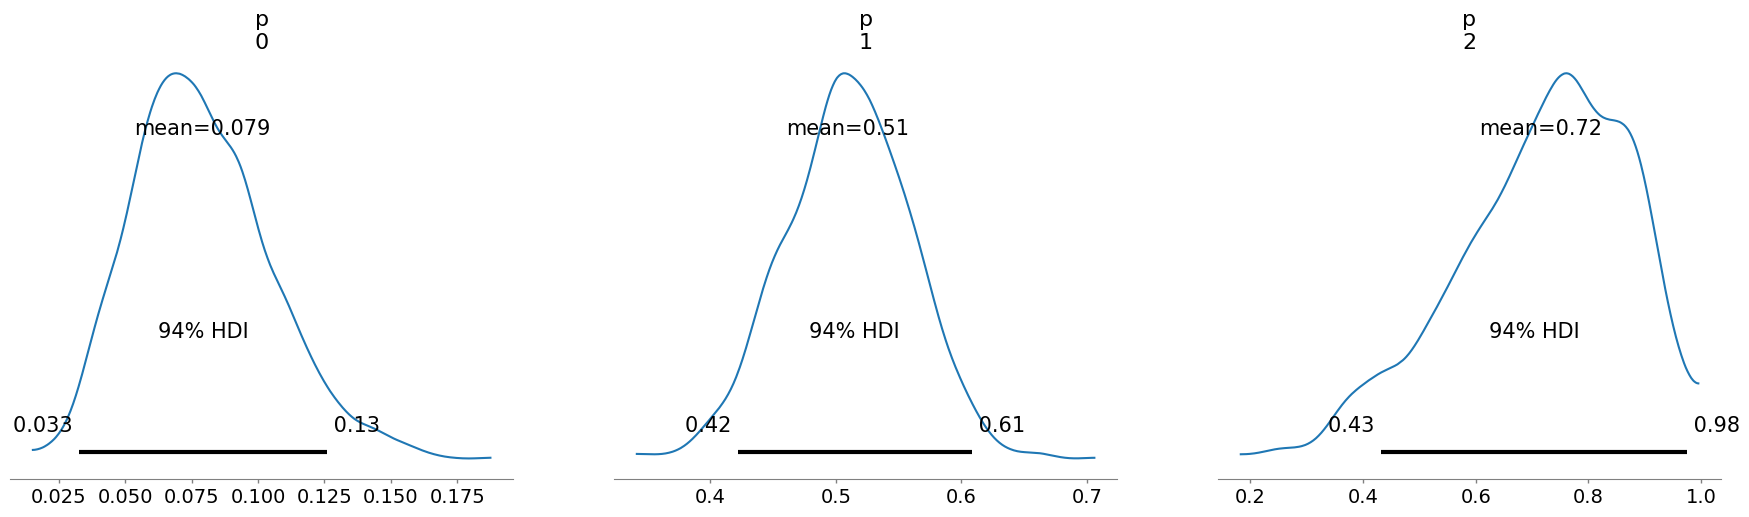

In [ ]:
az.plot_posterior(idata_vec)

#Shrinkage
- Go back up and rerun the code with `data[:,205]` uncommneted.

**Chat**,
1. Compare these two results. The first is from an independent model, the second from a hierarchical.
2. What's shrinkage? Do I know it by another name?
3. How is shrinkage built in in hierarchical models? Explain with my example of three (possibly) biased coins.
4. Show me common failure modes of shrinkage.

### Model Comparison
**Chat**,
1. I have two Bayesian models (non-nested), how do I choose between them?
2. Are my two models from before, with the coins, nested? Can I use the BF to compare them? WAIC?


WAIC ~ Bayesian AIC

In [ ]:
cmp_df = az.compare({"ind": idata_vec, "h": idata_h},ic="waic")
cmp_df

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
ind,0,-113.033605,2.802718,0.000000,1.0,7.105092,0.000000,False,log
h,1,-113.429728,2.829764,0.396124,0.0,6.816556,0.765581,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

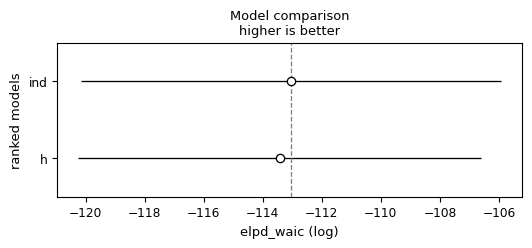

In [ ]:
az.plot_compare(cmp_df)

**Chat**,
1. Explain these results. <copy & paste>
2. Why do we measure "effective" no. of parameters?
3. does one use BIC with Bayesian models in general?